# The Notebook for Evaluating DRPT Anti-Integrin Model

This is the evaluation notebook for evaluating the performance of the Anti-Integrin DRPT model applied to the cell-line genomic profiles and response data that Nicole provided

In [41]:
import argparse
import os
import random
import shutil
import time
import warnings
from enum import Enum
import pandas as pd

import argparse
import torch
import torch.nn.parallel
import torch.distributed as dist
import torch.optim
import torch.multiprocessing as mp
import torch.utils.data
import torch.utils.data.distributed

from prettytable import PrettyTable

from src.model.compound import ECFPCompoundModel, ChemBERTaCompoundModel, DrugEmbeddingCompoundModel
from src.model.model.drug_response_model import DrugResponseModel
from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline, RobertaModel, RobertaTokenizer

from src.utils.data import CompoundEncoder
from src.utils.tree import MutTreeParser
from src.utils.data.dataset import DrugResponseDataset, DrugResponseCollator, DrugResponseSampler, DrugBatchSampler, DrugDataset, CellLineBatchSampler
from src.utils.trainer import DrugResponseTrainer, DrugTrainer, DrugResponseFineTuner
import numpy as np
import torch.nn as nn
import pickle
import pubchempy as pcp
import statistics as s
from torch.utils.data.dataloader import DataLoader
import matplotlib.pyplot as plt
import pandas as pd
import math
from operator import itemgetter
from scipy.stats import ttest_ind

import gc
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import  StepLR
from torch.nn.utils import prune
from sklearn import metrics
from scipy.stats import spearmanr, pearsonr
from tqdm import tqdm
import numpy as np
import copy
from transformers import get_linear_schedule_with_warmup
from src.utils.trainer import CCCLoss
from src.utils.data import move_to
import copy
from torch.nn import functional as F
import pickle

In [42]:
import os, sys

class HiddenPrints:
    def __enter__(self):
        self._original_stdout = sys.stdout
        sys.stdout = open(os.devnull, 'w')

    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stdout.close()
        sys.stdout = self._original_stdout

## Function for Instantiating the Model

In [43]:
def instantiate_model(train_dataset, saved_model, diff_transformer=True):

    train_dataset = pd.read_csv(train_dataset, header=None, sep='\t')
    onto = "data/ontology_ctg_av.txt"
    gene2id = "data/gene2ind_ctg_av.txt"
    genotypes = {'mutation': 'data/cell2mutation_integrin.txt', 'cna': 'data/cell2cnamplification_integrin.txt', 'cnd': 'data/cell2cndeletion_integrin.txt'}
    hidden_dims = 128
    dropout = 0.2
    batch_size = 32
    jobs = 16
    lr = 0.0001
    wd = 0.01


    with HiddenPrints():
        compound_encoder = CompoundEncoder('Embedding', dataset=train_dataset, out="dummy/")
        compound_model = DrugEmbeddingCompoundModel(compound_encoder.num_drugs(), hidden_dims)

        tree_parser = MutTreeParser(onto, gene2id)

        device = "cuda" if torch.cuda.is_available() else "cpu"

        drug_response_model = DrugResponseModel(tree_parser, list(genotypes.keys()), hidden_dims, compound_model, 
                                                dropout=dropout, diff_transformer=diff_transformer)
    
        model = torch.load(saved_model, map_location=torch.device(device))
        model = model["state_dict"]

        drug_response_model.load_state_dict(model)
        drug_response_model.to(device)

        return(drug_response_model)

## Evaluation Functions (Pearson or Odds Ratio)

In [44]:
def evaluate_model(train_dataset, test_dataset, model, sys2cell, cell2sys, sys2gene, gene2drug, mut2gene, with_indices, method="pearson"):
    
    train_dataset = pd.read_csv(train_dataset, header=None, sep='\t')
    test_dataset = pd.read_csv(test_dataset, header=None, sep='\t')
    onto = "data/ontology_ctg_av.txt"
    gene2id = "data/gene2ind_ctg_av.txt"
    cell2id = "data/cell2ind_integrin.txt"
    genotypes = {'mutation': 'data/cell2mutation_integrin.txt', 'cna': 'data/cell2cnamplification_integrin.txt', 'cnd': 'data/cell2cndeletion_integrin.txt'}
    jobs = 16
    batch_size = 32

    device = "cuda" if torch.cuda.is_available() else "cpu"

    with HiddenPrints():
        compound_encoder = CompoundEncoder('Embedding', dataset=train_dataset, out="dummy/") # Keep this same as train dataset
        tree_parser = MutTreeParser(onto, gene2id)
    
        test_drug_response_dataset = DrugResponseDataset(test_dataset, cell2id, genotypes, compound_encoder, tree_parser, 
                                                         mut2gene=mut2gene, with_indices=with_indices)
        drug_response_collator = DrugResponseCollator(tree_parser, list(genotypes.keys()), compound_encoder, 
                                                      mut2gene=mut2gene, with_indices=with_indices)
        test_drug_response_dataloader = DataLoader(test_drug_response_dataset, shuffle=False, batch_size=batch_size,
                                                   num_workers=jobs, collate_fn=drug_response_collator)
        torch.cuda.empty_cache()

        if method == "pearson":
            performance = evaluate(model, test_drug_response_dataloader, device, sys2cell, cell2sys, sys2gene, 
                                   gene2drug, mut2gene, with_indices, "pearson")
        elif method == "odds ratio":
            performance = evaluate(model, test_drug_response_dataloader, device, sys2cell, cell2sys, sys2gene, 
                                   gene2drug, mut2gene, with_indices, "odds ratio")
            
        return performance

### Main Evaluation Helper Function

In [45]:
def evaluate(model, dataloader, device, sys2cell, cell2sys, sys2gene, gene2drug, mut2gene, with_indices, method):
    
    trues = []
    results = []
    performance = {}

    test_df = dataloader.dataset.drug_response_df.reset_index()
    test_grouped = test_df.reset_index().groupby(1)
    nested_subtrees_forward = move_to(dataloader.dataset.tree_parser.get_nested_subtree_mask(['default'], direction='forward'), device)
    nested_subtrees_backward = move_to(dataloader.dataset.tree_parser.get_nested_subtree_mask(['default'], direction='backward'), device)
    gene2system_mask = move_to(torch.tensor(dataloader.dataset.tree_parser.gene2sys_mask, dtype=torch.bool), device)
    system2gene_mask = move_to(torch.tensor(dataloader.dataset.tree_parser.sys2gene_mask, dtype=torch.bool), device)
    
    model.to(device)
    model.eval()
    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            trues.append(batch['response_mean'] + batch['response_residual'])
            batch = move_to(batch, device)
            drug_response_predicted = model(batch['genotype'], batch['drug'],
                                            nested_subtrees_forward, nested_subtrees_backward,
                                            gene2system_mask,
                                            system2gene_mask,
                                            sys2cell=sys2cell, 
                                            cell2sys=cell2sys, 
                                            sys2gene=sys2gene, 
                                            gene2drug=gene2drug, 
                                            mut2gene=mut2gene, 
                                            with_indices=with_indices)
            drug_response_predicted_detached = drug_response_predicted.detach().cpu().numpy()
            results.append(drug_response_predicted_detached)
            del drug_response_predicted
            del drug_response_predicted_detached
            del batch
            
    results = np.concatenate(results)[:, 0]
    
    for drug, indice in test_grouped.groups.items():
        if len(indice) <= 1:
            continue
        if method == "pearson":
            pearson = pearsonr(test_df.loc[indice][2], results[indice])[0]
            performance[drug] = pearson
        elif method == "odds ratio":
            true, predicted = np.asarray(test_df.loc[indice][2]), np.asarray(results[indice])
            odds = odds_ratio(true, predicted)
            performance[drug] = odds

    return performance

### Odds Ratio Helper Functions

In [46]:
def odds_ratio(test, predict):
    
    cell_drug_auc_true = dict(zip(list(range(0, len(test), 1)), test))
    cell_drug_auc_pred = dict(zip(list(range(0, len(predict), 1)), predict))
    cell_drug_auc_true = {k: v for k, v in cell_drug_auc_true.items() if not math.isnan(v)}
    cell_drug_auc_pred = {k: v for k, v in cell_drug_auc_pred.items() if cell_drug_auc_true.get(k)}
    
    top_res_true, top_sen_true = top_res_sen(cell_drug_auc_true, 0.25)
    top_res_pred, top_sen_pred = top_res_sen(cell_drug_auc_pred, 0.50)
    
    true_res_pred_res = len(list(set(top_res_true).intersection(set(top_res_pred))))
    true_res_pred_sen = len(list(set(top_res_true).intersection(set(top_sen_pred))))
    true_sen_pred_res = len(list(set(top_sen_true).intersection(set(top_res_pred))))
    true_sen_pred_sen = len(list(set(top_sen_true).intersection(set(top_sen_pred))))

    odds = (true_res_pred_res * true_sen_pred_sen) / (true_res_pred_sen * true_sen_pred_res)

    return(odds)

# Expect a dict of of drug response for a cell-line (cell-line could just be index)
# Top N resistance and sensitive cell-lines
def top_res_sen(cell_drug_auc, percentile):
    
    N = math.floor(percentile*len(cell_drug_auc))
    top_N_res = list(dict(sorted(cell_drug_auc.items(), key=itemgetter(1), reverse=True)[:N]).keys())
    top_N_sen = list(dict(sorted(cell_drug_auc.items(), key=itemgetter(1), reverse=False)[:N]).keys())

    return(top_N_res, top_N_sen)

## Evaluate DRPT Integrin

In [47]:
loaded = torch.load('models_integrin_150/integrin_model_0.pt', map_location=torch.device('cpu'))
print(loaded['arguments'])

Namespace(batch_size=32, bert=None, cell2id='data/cell2ind_integrin.txt', cell2sys=True, compound_epochs=10, compound_layers=[256], cuda=0, diff_transformer=True, dist_backend='nccl', dist_url='tcp://224.66.41.62:23456', distributed=False, dropout=0.2, drug_embedding=True, epochs=150, gene2drug=False, gene2id='data/gene2ind_ctg_av.txt', gene_embedding=None, genotypes={'mutation': 'data/cell2mutation_integrin.txt', 'cna': 'data/cell2cnamplification_integrin.txt', 'cnd': 'data/cell2cndeletion_integrin.txt'}, gpu=0, hidden_dims=128, jobs=16, l2_lambda=0.01, local_rank=1, lr=0.0001, model=None, multiprocessing_distributed=False, mut2gene=True, n_bits=512, onto='data/ontology_ctg_av.txt', out='models_integrin_150/integrin_model_0.pt', radius=2, rank=-1, seed=None, subtree_order=['default'], sys2cell=True, sys2gene=False, system_embedding=None, test='data/train_splits/test_dataset_integrin_0.txt', train='data/train_splits/train_dataset_integrin_full_0.txt', val='data/train_splits/test_datase

### Instantiate and Evaluate DRPT (Pearson and Odds)

In [50]:
def evaluate_drpt(model_dir):
    drpt_pearson = []
    drpt_odds = []
    for i in range(5):
        train = 'data/train_splits/train_dataset_integrin_full_'+str(i)+'.txt'
        test = 'data/train_splits/test_dataset_integrin_'+str(i)+'.txt'
        model = model_dir+'/integrin_model_'+str(i)+'.pt'
        model_i = instantiate_model(train, model)
        performance_i_pearson = evaluate_model(train, test, model_i, sys2cell=True, cell2sys=True, sys2gene=False, gene2drug=False, 
                                               mut2gene=True, with_indices=True, method="pearson")
        performance_i_odds = evaluate_model(train, test, model_i, sys2cell=True, cell2sys=True, sys2gene=False, gene2drug=False, 
                                            mut2gene=True, with_indices=True, method="odds ratio")
        drpt_pearson.append(performance_i_pearson)
        drpt_odds.append(performance_i_odds)

    return(drpt_pearson, drpt_odds)

In [51]:
drpt_pearson_150, drpt_odds_150 = evaluate_drpt("models_integrin_150")
drpt_pearson_160, drpt_odds_160 = evaluate_drpt("models_integrin_160")
drpt_pearson_170, drpt_odds_170 = evaluate_drpt("models_integrin_170")
drpt_pearson_180, drpt_odds_180 = evaluate_drpt("models_integrin_180")
drpt_pearson_190, drpt_odds_190 = evaluate_drpt("models_integrin_190")
drpt_pearson_200, drpt_odds_200 = evaluate_drpt("models_integrin_200")

### Which Epoch has the Best Results for the Two Drugs?

In [69]:
results = [drpt_pearson_150, drpt_pearson_160, drpt_pearson_170, 
           drpt_pearson_180, drpt_pearson_190, drpt_pearson_200]

epochs = [150, 160, 170, 180, 190, 200]

for i in range(len(results)):
    cilg = []
    cpd2 = []
    both = []
    for result in results[i]:
        cilg.append(result["Cilengitide"])
        cpd2.append(result["Cpd_2"])
        both.append(result["Cilengitide"])
        both.append(result["Cpd_2"])

    print("Epoch", epochs[i], "-", "Cilengitide:", np.mean(cilg), "Cpd_2:", np.mean(cpd2), "Both:", np.mean(both))    

Epoch 150 - Cilengitide: 0.1262523500816357 Cpd_2: 0.11885002270525957 Both: 0.12255118639344764
Epoch 160 - Cilengitide: 0.10586105495076747 Cpd_2: 0.14716300620335085 Both: 0.12651203057705915
Epoch 170 - Cilengitide: 0.11730368005081679 Cpd_2: 0.08010194527591498 Both: 0.09870281266336589
Epoch 180 - Cilengitide: 0.07401093464517314 Cpd_2: 0.10420156789059583 Both: 0.08910625126788449
Epoch 190 - Cilengitide: 0.10235630402334932 Cpd_2: 0.10897451394972865 Both: 0.105665408986539
Epoch 200 - Cilengitide: 0.10150437449785935 Cpd_2: 0.10929745610837445 Both: 0.10540091530311688


In [72]:
results = [drpt_odds_150, drpt_odds_160, drpt_odds_170, 
           drpt_odds_180, drpt_odds_190, drpt_odds_200]

epochs = [150, 160, 170, 180, 190, 200]

for i in range(len(results)):
    cilg = []
    cpd2 = []
    both = []
    for result in results[i]:
        cilg.append(result["Cilengitide"])
        cpd2.append(result["Cpd_2"])
        both.append(result["Cilengitide"])
        both.append(result["Cpd_2"])

    print("Epoch", epochs[i], "-", "Cilengitide:", np.mean(cilg), "Cpd_2:", np.mean(cpd2), "Both:", np.mean(both))    

Epoch 150 - Cilengitide: 2.4603830728095435 Cpd_2: 1.6780926182415101 Both: 2.0692378455255267
Epoch 160 - Cilengitide: 2.164940811625022 Cpd_2: 1.9244919786096255 Both: 2.044716395117324
Epoch 170 - Cilengitide: 2.1205702372775668 Cpd_2: 1.696487232574189 Both: 1.9085287349258777
Epoch 180 - Cilengitide: 2.0787097373062284 Cpd_2: 1.4828151037129367 Both: 1.7807624205095824
Epoch 190 - Cilengitide: 2.225785821505636 Cpd_2: 1.8711988229635288 Both: 2.0484923222345826
Epoch 200 - Cilengitide: 1.628093567251462 Cpd_2: 1.2663823554325364 Both: 1.4472379613419988


### Create Side-by-Side Error Bar Plots

In [52]:
from scipy.stats import sem

#### Odds Ratio

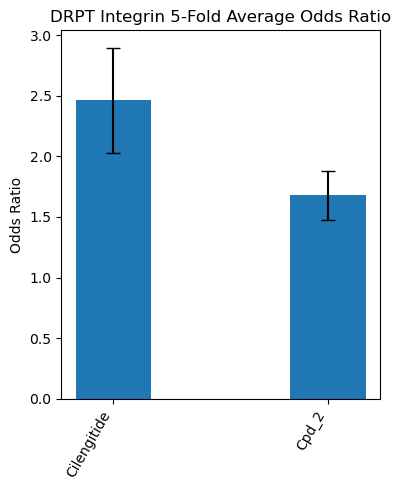

In [73]:
A = drpt_odds_150

# Convert the lists of dictionaries into DataFrames
df_A = pd.DataFrame(A)

# Calculate the mean and standard error of the mean for each drug
mean_values_A = df_A.mean()
error_values_A = pd.Series(sem(df_A, axis=0), index=df_A.columns)

# Sort the drugs by their average odds ratio values in A in descending order
sorted_indices = mean_values_A.sort_values(ascending=False).index
mean_values_A = mean_values_A.loc[sorted_indices]
error_values_A = error_values_A.loc[sorted_indices]

# Plotting
x = np.arange(len(mean_values_A))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(4, 5))

# Bar plot for A
rects1 = ax.bar(x, mean_values_A, width, yerr=error_values_A, capsize=5)

# Add labels, title, and legend
ax.set_ylabel('Odds Ratio')
ax.set_title('DRPT Integrin 5-Fold Average Odds Ratio', fontsize = 12)
ax.set_xticks(x)
ax.set_xticklabels(mean_values_A.index, rotation=60, ha='right')

fig.tight_layout()

plt.show()

#### Pearson Correlation

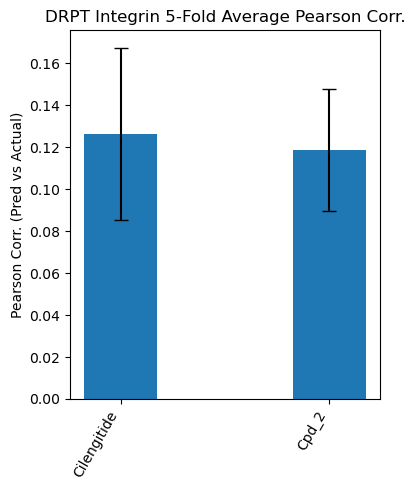

In [76]:
A = drpt_pearson_150

# Convert the lists of dictionaries into DataFrames
df_A = pd.DataFrame(A)

# Calculate the mean and standard error of the mean for each drug
mean_values_A = df_A.mean()
error_values_A = pd.Series(sem(df_A, axis=0), index=df_A.columns)

# Sort the drugs by their average odds ratio values in A in descending order
sorted_indices = mean_values_A.sort_values(ascending=False).index
mean_values_A = mean_values_A.loc[sorted_indices]
error_values_A = error_values_A.loc[sorted_indices]

# Plotting
x = np.arange(len(mean_values_A))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(4, 5))

# Bar plot for A
rects1 = ax.bar(x, mean_values_A, width, yerr=error_values_A, capsize=5)

# Add labels, title, and legend
ax.set_ylabel('Pearson Corr. (Pred vs Actual)')
ax.set_title('DRPT Integrin 5-Fold Average Pearson Corr.', fontsize = 12)
ax.set_xticks(x)
ax.set_xticklabels(mean_values_A.index, rotation=60, ha='right')

fig.tight_layout()

plt.show()

## Explore Epoch Loss and Val Performance

In [15]:
def open_pickle(file):
    
    with open(file, "rb") as handle:
        result = pickle.load(handle)
        
    return(result)

In [16]:
val_0 = open_pickle("models_integrin/val_performance_0.pt.pkl")
val_1 = open_pickle("models_integrin/val_performance_1.pt.pkl")
val_2 = open_pickle("models_integrin/val_performance_2.pt.pkl")
val_3 = open_pickle("models_integrin/val_performance_3.pt.pkl")
val_4 = open_pickle("models_integrin/val_performance_4.pt.pkl")

In [17]:
val_0

{10: {'pearson_per_drug': {'Cilengitide': -0.020680119463661363,
   'Cpd_2': 0.04262625520235171},
  'spearman_per_drug': {'Cilengitide': -0.03182454940923401,
   'Cpd_2': 0.04280808527667254}},
 20: {'pearson_per_drug': {'Cilengitide': -0.05082646425656087,
   'Cpd_2': 0.06766830570302214},
  'spearman_per_drug': {'Cilengitide': -0.0437062507402019,
   'Cpd_2': 0.06673019369790693}},
 30: {'pearson_per_drug': {'Cilengitide': -0.003322855075335557,
   'Cpd_2': 0.07244810631703902},
  'spearman_per_drug': {'Cilengitide': -5.3621818718170204e-05,
   'Cpd_2': 0.05846342209993165}},
 40: {'pearson_per_drug': {'Cilengitide': 0.03307341761176571,
   'Cpd_2': 0.06443618504934488},
  'spearman_per_drug': {'Cilengitide': 0.03846471796050076,
   'Cpd_2': 0.06162264091941051}},
 50: {'pearson_per_drug': {'Cilengitide': 0.0881904080452258,
   'Cpd_2': 0.06692587775059247},
  'spearman_per_drug': {'Cilengitide': 0.09971647463377725,
   'Cpd_2': 0.06262358153548302}},
 60: {'pearson_per_drug': {'Cil

In [18]:
def best_epoch(val_performance, metric):

    metric = metric + "_per_drug"
    names = ['Cilengitide', 'Cpd_2']
    best_performance_drugs = {name: -1 for name in names}
    best_epoch_drugs = {name: 0 for name in names}
    best_performance_all = 0
    best_epoch_all = 0
    for epoch in val_performance.keys():
        performance = val_performance[epoch]
        performance = performance[metric]
        mean_performance = s.mean(list(performance.values()))
        if mean_performance > best_performance_all:
            best_performance_all = mean_performance
            best_epoch_all = epoch
        for drug in performance.keys():
            eval_value = performance[drug]
            if eval_value > best_performance_drugs[drug]:
                best_performance_drugs[drug] = eval_value
                best_epoch_drugs[drug] = epoch

    for drug in best_performance_drugs.keys():
        print(f"Best {metric} for {drug}: {best_performance_drugs[drug]} | Epoch: {best_epoch_drugs[drug]}")
    
    print(f"Best mean {metric}: {best_performance_all} | Epoch: {best_epoch_all}")

In [19]:
print("Fold 1\n")
best_epoch(val_0, "pearson")
print("\n")
print("Fold 2\n")
best_epoch(val_1, "pearson")
print("\n")
print("Fold 3\n")
best_epoch(val_2, "pearson")
print("\n")
print("Fold 4\n")
best_epoch(val_3, "pearson")
print("\n")
print("Fold 5\n")
best_epoch(val_4, "pearson")
print("\n")

Fold 1

Best pearson_per_drug for Cilengitide: 0.22514098584932565 | Epoch: 100
Best pearson_per_drug for Cpd_2: 0.12808416463552383 | Epoch: 320
Best mean pearson_per_drug: 0.16120535340997338 | Epoch: 130


Fold 2

Best pearson_per_drug for Cilengitide: 0.08484920094460965 | Epoch: 20
Best pearson_per_drug for Cpd_2: 0.16677557995554693 | Epoch: 180
Best mean pearson_per_drug: 0.09677864693919917 | Epoch: 180


Fold 3

Best pearson_per_drug for Cilengitide: 0.23733090673138213 | Epoch: 170
Best pearson_per_drug for Cpd_2: 0.2549288032139785 | Epoch: 150
Best mean pearson_per_drug: 0.23760440148370976 | Epoch: 170


Fold 4

Best pearson_per_drug for Cilengitide: 0.17602179647012262 | Epoch: 70
Best pearson_per_drug for Cpd_2: 0.17422502083589755 | Epoch: 310
Best mean pearson_per_drug: 0.13983358182237846 | Epoch: 180


Fold 5

Best pearson_per_drug for Cilengitide: 0.10143137465245486 | Epoch: 200
Best pearson_per_drug for Cpd_2: 0.11467450838775659 | Epoch: 30
Best mean pearson_per_

In [31]:
def validation_performance(val_performances):

    mean_drug_performance = {}
    best_epoch_cil = 0
    best_perform_cil = 0
    best_epoch_cpd = 0
    best_perform_cpd = 0
    for val in val_performances:
        for epoch in val.keys():
            pearsons = val[epoch]["pearson_per_drug"]
            for drug in pearsons.keys():
                name = drug
                if mean_drug_performance.get(epoch):
                    if mean_drug_performance[epoch].get(name):
                        mean_drug_performance[epoch][name] += pearsons[drug]/len(val_performances)
                    else:
                        mean_drug_performance[epoch][name] = pearsons[drug]/len(val_performances)
                else:
                    mean_drug_performance[epoch] = {}
                    mean_drug_performance[epoch][name] = pearsons[drug]/len(val_performances)

            if mean_drug_performance[epoch]["Cilengitide"] > best_perform_cil:
                best_perform_cil = mean_drug_performance[epoch]["Cilengitide"]
                best_epoch_cil = epoch
            if mean_drug_performance[epoch]["Cpd_2"] > best_perform_cpd:
                best_perform_cpd = mean_drug_performance[epoch]["Cpd_2"]
                best_epoch_cpd = epoch

    print("Best Epoch Cilengitide:", best_epoch_cil)
    print("Best Epoch Cpd-2:", best_epoch_cpd)
    
    epochs = list(mean_drug_performance.keys())
    drugs = list(mean_drug_performance[epochs[0]].keys())

    plt.figure(figsize=(10, 6))

    for drug in drugs:
        values = [mean_drug_performance[epoch][drug] for epoch in epochs]
        plt.plot(epochs, values, label=drug)

    plt.title('Mean Validation Set Performance at each Epoch Across 5-Folds')
    plt.xlabel('Epoch')
    plt.ylabel('5-Fold Mean Pearson Correlation ')
    plt.legend(title='Drugs')

    plt.show()

Best Epoch Cilengitide: 170
Best Epoch Cpd-2: 180


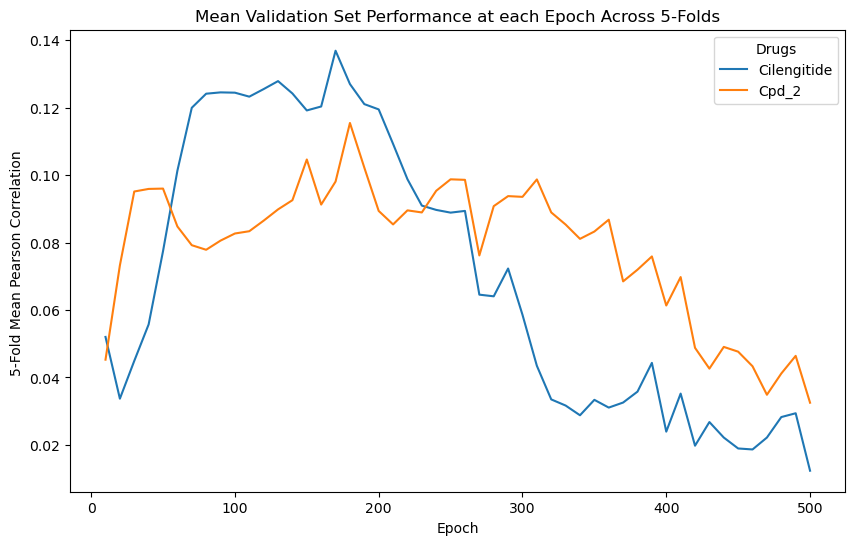

In [32]:
val_performances = [val_0, val_1, val_2, val_3, val_4]
validation_performance(val_performances)